In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/ImageProcessing/Lab3_2/'

Mounted at /content/drive


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

Exercise 1: image enhancement in spatial domainusinghistogram equalization

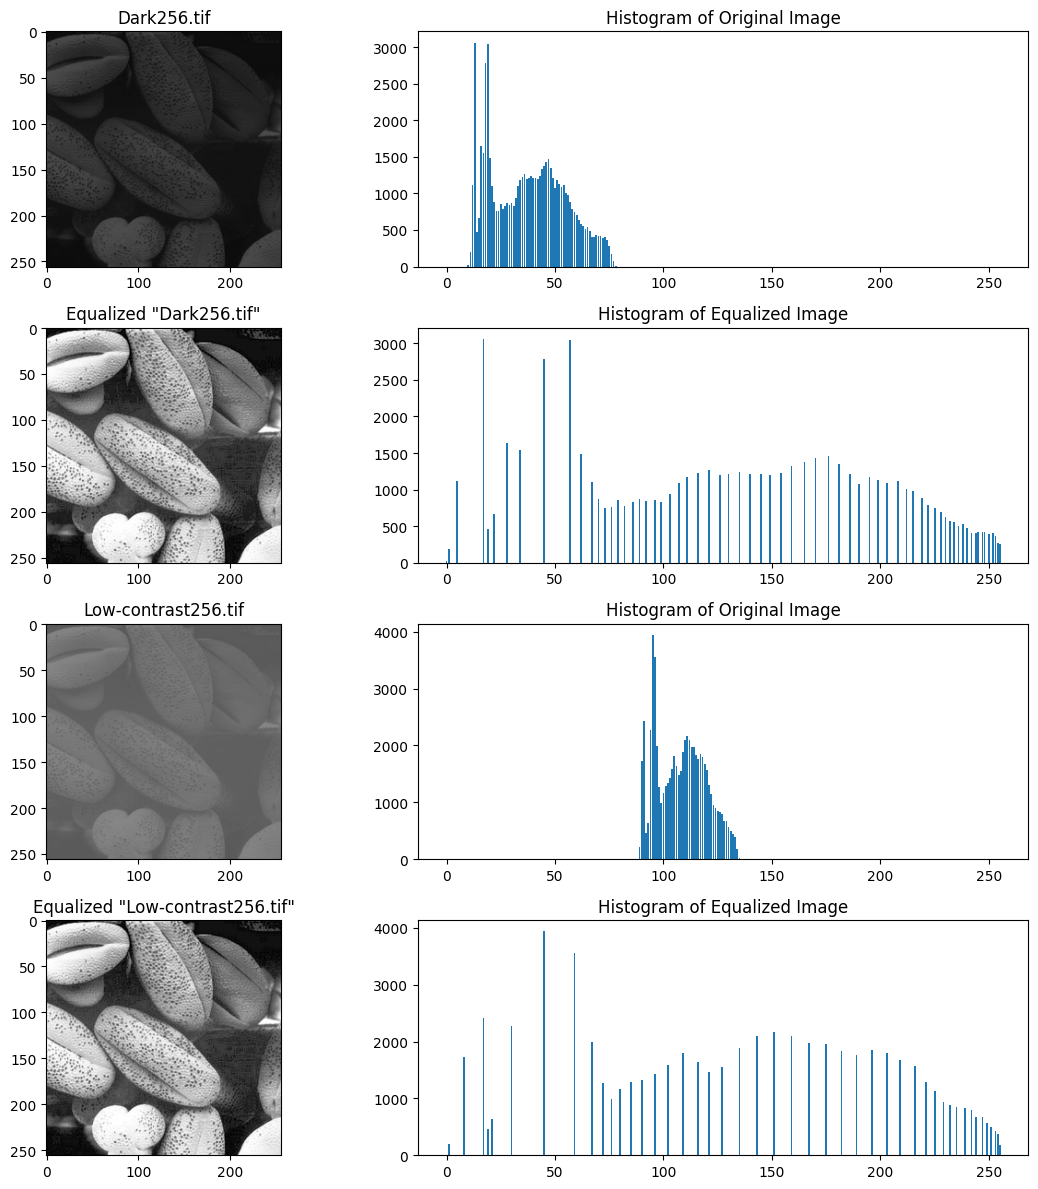

In [5]:
image1_path = path + "Dark256.tif"
image2_path = path + "Low-contrast256.tif"


def Equalized(image):
  prob = np.zeros(256, dtype=float)
  culm = np.zeros(256, dtype=float)
  s_k = np.zeros(256, dtype=int)
  n_k = np.zeros(256, dtype=int)
  new_n_k = np.zeros(256, dtype=int)

  for i in range (image.shape[0]):
    for j in range (image.shape[1]):
        gray = image[i,j]
        n_k[gray] +=1

  for i in range (256):
    prob[i] = n_k[i] / (image.shape[0] * image.shape[1])

  for i in range (256):
    culm[i] = culm[i-1] + prob[i]

  for i in range (256):
    s_k[i] = round(255 * culm[i])

  for i in range(256):
    new_n_k[s_k[i]] += n_k[i]

  return s_k, new_n_k, n_k

def Myhisteq(image1_path, image2_path):

  image1 = cv2.imread(image1_path)
  image2 = cv2.imread(image2_path)

  ############ Image1 ####################

  s_k, new_n_k, n_k = Equalized(image1)

  equalized_image1 = s_k[image1]

  plt.figure(figsize=(12,12))

  plt.subplot(4,2,1)
  plt.title('Dark256.tif')
  plt.imshow(image1, vmin=0, vmax=255)

  plt.subplot(4,2,3)
  plt.title('Equalized "Dark256.tif"')
  plt.imshow(equalized_image1, vmin=0, vmax=255)

  # histograms
  plt.subplot(4,2,2)
  plt.bar(np.arange(256), n_k)
  plt.title('Histogram of Original Image')

  plt.subplot(4,2,4)
  plt.bar(np.arange(256), new_n_k)
  plt.title('Histogram of Equalized Image')

  ############ Image2 ####################

  s_k, new_n_k, n_k = Equalized(image2)

  equalized_image2 = s_k[image2]

  plt.subplot(4,2,5)
  plt.title('Low-contrast256.tif')
  plt.imshow(image2, vmin=0, vmax=255)

  plt.subplot(4,2,7)
  plt.title('Equalized "Low-contrast256.tif"')
  plt.imshow(equalized_image2, vmin=0, vmax=255)

  # histograms
  plt.subplot(4,2,6)
  plt.bar(np.arange(256), n_k)
  plt.title('Histogram of Original Image')

  plt.subplot(4,2,8)
  plt.bar(np.arange(256), new_n_k)
  plt.title('Histogram of Equalized Image')

  plt.tight_layout()
  plt.show()



#####################################################

Myhisteq(image1_path,image2_path)



Exercise 2: image enhancement in the spatial domainusingimage averaging

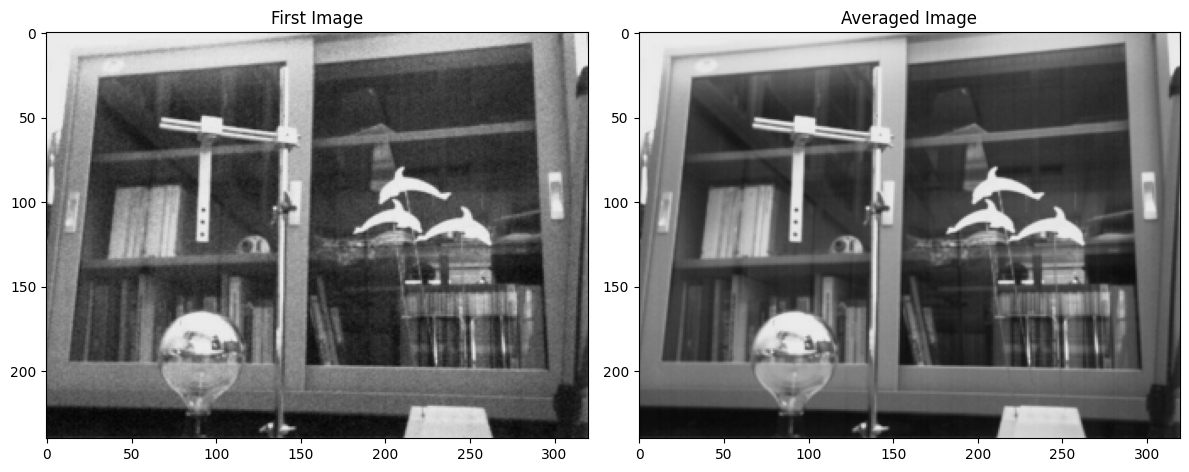

In [14]:
image_paths = [f"{path}p{i}.bmp" for i in range(1, 17)]

def Myimaver(image_paths):

    first_image = cv2.imread(image_paths[0])
    sum_image = np.zeros_like(first_image, dtype=np.float64)

    for p in image_paths:
        img = cv2.imread(p)
        sum_image += img

    avg_image = sum_image / len(image_paths)

    avg_image_uint8 = np.clip(avg_image, 0, 255).astype(np.uint8)

    return avg_image_uint8

avg_img = Myimaver(image_paths)

plt.figure(figsize=(12,6))

first_img = cv2.imread(image_paths[0])
plt.subplot(1,2,1)
plt.imshow(first_img, cmap='gray')
plt.title('First Image')

plt.subplot(1,2,2)
plt.imshow(avg_img, cmap='gray')
plt.title('Averaged Image')

plt.tight_layout()
plt.show()

